   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 97.1 MB/s eta 0:00:00
Dependencies installed
Select your HEIC files:


Saving 2.6.png to 2.6.png
2.6.png -> converted/2.6.png

Done - 1 file(s) converted.


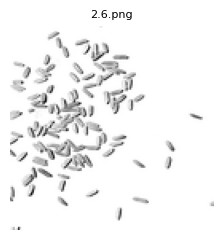


ZIP created: converted_images.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!apt-get install -y libheif-dev libheif1 > /dev/null 2>&1
!pip install pillow-heif Pillow --quiet
print("Dependencies installed")

from google.colab import files
print("Select your HEIC files:")
uploaded = files.upload()

import io
import shutil
from pathlib import Path
from PIL import Image
from pillow_heif import register_heif_opener

register_heif_opener()

OUTPUT_DIR = Path("converted")
OUTPUT_DIR.mkdir(exist_ok=True)

converted = []

for filename, data in uploaded.items():
    try:
        img = Image.open(io.BytesIO(data))
        img = img.convert("L")
        img = img.resize((128, 128), Image.LANCZOS)

        out_path = OUTPUT_DIR / (Path(filename).stem + ".png")
        img.save(out_path, format="PNG")

        converted.append(out_path)
        print(f"{filename} -> {out_path}")

    except Exception as e:
        print(f"Failed: {filename} - {e}")

print(f"\nDone - {len(converted)} file(s) converted.")

import matplotlib.pyplot as plt

if len(converted) > 0:
    cols = min(len(converted), 4)
    rows = (len(converted) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))

    if len(converted) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, path in zip(axes, converted):
        ax.imshow(Image.open(path), cmap="gray", vmin=0, vmax=255)
        ax.set_title(path.name, fontsize=8)
        ax.axis("off")

    for ax in axes[len(converted):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No se convirtió ningún archivo, por lo tanto no hay vista previa.")

if len(converted) > 0:
    ZIP_NAME = "converted_images"

    shutil.make_archive(ZIP_NAME, "zip", OUTPUT_DIR)

    print(f"\nZIP created: {ZIP_NAME}.zip")
    files.download(f"{ZIP_NAME}.zip")
else:
    print("No hay archivos para comprimir.")